<a href="https://colab.research.google.com/github/fiap-ia-2025/chap01-phase02-automate-diagnostics/blob/main/src/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📚 Introdução

A análise de sinais cardíacos é fundamental para o diagnóstico precoce de doenças cardiovasculares. O eletrocardiograma (ECG) é uma das principais ferramentas utilizadas na avaliação da atividade elétrica do coração, permitindo a identificação de padrões normais e anormais.

Com o avanço da Inteligência Artificial, técnicas de aprendizado de máquina têm sido amplamente aplicadas para automatizar a análise desses sinais, auxiliando profissionais da saúde na triagem e tomada de decisão.

Neste trabalho, propõe-se a utilização de uma Rede Neural Artificial do tipo Perceptron Multicamadas (MLP) para classificar imagens de ECG em duas categorias: normal e anormal. O objetivo é avaliar a capacidade do modelo em identificar padrões relevantes nas imagens e analisar seu desempenho em um contexto de diagnóstico assistido por IA.

## 🗂️ Dataset

O dataset utilizado é composto por imagens de eletrocardiogramas (ECG), derivadas de bases amplamente utilizadas na literatura, como MIT-BIH e PTB Diagnostic Database.

As imagens estão organizadas em múltiplas classes, representando diferentes tipos de batimentos cardíacos. Para adequação ao problema proposto, foi realizada uma transformação para classificação binária, considerando:

- Classe **N (Normal)** → 0 (normal)
- Demais classes (**F, M, S, Q, V**) → 1 (anormal)

Essa abordagem simplifica o problema e o torna mais alinhado com aplicações reais de triagem médica, onde o principal objetivo é identificar rapidamente padrões anormais.

In [38]:
import kagglehub

# ================================
# DOWNLOAD DO DATASET
# ================================

# Utiliza o kagglehub para baixar automaticamente o dataset de imagens de ECG
# O dataset contém imagens organizadas em pastas por classe
# (ex: Normal, Anormal, etc.)

print("Baixando dataset do Kaggle...")

# Faz o download da versão mais recente do dataset
path = kagglehub.dataset_download("erhmrai/ecg-image-data")

# Exibe o caminho onde os arquivos foram armazenados
print("Caminho do dataset:", path)

Baixando dataset do Kaggle...
Using Colab cache for faster access to the 'ecg-image-data' dataset.
Caminho do dataset: /kaggle/input/ecg-image-data


In [39]:
import os

# ================================
# EXPLORAÇÃO DO DIRETÓRIO DO DATASET
# ================================

# Lista os arquivos/pastas presentes no diretório baixado
# Isso ajuda a entender a estrutura do dataset
print("Conteúdo do diretório baixado:")
print(os.listdir(path))

# ================================
# DEFINIÇÃO DO CAMINHO BASE
# ================================

# Em muitos datasets do Kaggle, os arquivos vêm dentro de uma pasta principal
# Aqui pegamos automaticamente essa primeira pasta
base_folder = os.listdir(path)[0]

# Monta o caminho completo até essa pasta
base_path = os.path.join(path, base_folder)

# Exibe o caminho final que será usado para carregar as imagens
print("\nCaminho base do dataset:", base_path)

Conteúdo do diretório baixado:
['ECG_Image_data']

Caminho base do dataset: /kaggle/input/ecg-image-data/ECG_Image_data


In [40]:
import os

# ================================
# DEFINIÇÃO DOS CAMINHOS DO DATASET
# ================================

# Inicializa variáveis de caminho
train_path = None
test_path = None

try:
    import kagglehub

    print("Baixando dataset via kagglehub...")

    # Download do dataset do Kaggle
    path = kagglehub.dataset_download("erhmrai/ecg-image-data")

    print("Dataset disponível em:", path)

    # ================================
    # IDENTIFICAÇÃO DA PASTA PRINCIPAL
    # ================================

    # Alguns datasets vêm dentro de uma pasta interna
    # Aqui detectamos automaticamente essa pasta
    folders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]

    base_folder = folders[0]
    base_path = os.path.join(path, base_folder)

    # ================================
    # DEFINIÇÃO DOS CAMINHOS DE TREINO E TESTE
    # ================================

    train_path = os.path.join(base_path, "train")
    test_path = os.path.join(base_path, "test")

except Exception as e:
    print("Erro ao usar kagglehub:", e)
    print("Usando caminho local...")

    # Caminhos alternativos (caso o download falhe)
    train_path = "dataset/train"
    test_path = "dataset/test"

# ================================
# VALIDAÇÃO DOS CAMINHOS
# ================================

# Garante que as pastas existem antes de continuar
assert os.path.exists(train_path), f"Pasta não encontrada: {train_path}"
assert os.path.exists(test_path), f"Pasta não encontrada: {test_path}"

# ================================
# EXPLORAÇÃO DAS CLASSES
# ================================

# Lista as classes disponíveis (subpastas)
print("\nClasses no conjunto de treino:")
print(os.listdir(train_path))

print("\nClasses no conjunto de teste:")
print(os.listdir(test_path))

Baixando dataset via kagglehub...
Using Colab cache for faster access to the 'ecg-image-data' dataset.
Dataset disponível em: /kaggle/input/ecg-image-data

Classes no conjunto de treino:
['N', 'F', 'M', 'Q', 'S', 'V']

Classes no conjunto de teste:
['N', 'F', 'M', 'Q', 'S', 'V']


## 🛠️ Pré-processamento dos Dados

As imagens passaram por uma etapa de pré-processamento para torná-las compatíveis com a rede neural MLP. As seguintes etapas foram aplicadas:

- Conversão para escala de cinza (grayscale)
- Redimensionamento para um tamanho fixo (64x64 pixels)
- Normalização dos valores de pixel para o intervalo [0, 1]
- Transformação das imagens em vetores unidimensionais (flatten)

A etapa de flatten é necessária, pois a MLP recebe dados em formato vetorial, diferentemente de modelos mais avançados como CNNs, que operam diretamente em estruturas bidimensionais.

In [41]:
import cv2
import numpy as np
import os

# ================================
# CONFIGURAÇÃO
# ================================

# Define o tamanho padrão das imagens (64x64)
IMG_SIZE = 64

# ================================
# FUNÇÃO DE CARREGAMENTO DE IMAGENS
# ================================

def load_images(base_path, limit_per_class=300):
    """
    Carrega imagens de um diretório estruturado por classes e realiza o pré-processamento.

    Parâmetros:
    - base_path: caminho base onde estão as pastas das classes
    - limit_per_class: número máximo de imagens por classe (para balanceamento)

    Retorna:
    - data: array numpy com as imagens processadas (flatten)
    - labels: array numpy com os rótulos (0 = normal, 1 = anormal)
    """

    data = []
    labels = []
    errors = 0

    # ================================
    # MAPEAMENTO DAS CLASSES
    # ================================

    # Converte múltiplas classes em binário:
    # N = Normal (0)
    # Outras classes = Anormal (1)
    label_map = {
        "N": 0,
        "F": 1,
        "M": 1,
        "S": 1,
        "Q": 1,
        "V": 1
    }

    # ================================
    # LEITURA DAS IMAGENS
    # ================================

    for label in label_map:
        path = os.path.join(base_path, label)

        # Verifica se a pasta existe
        if not os.path.exists(path):
            print(f"Pasta não encontrada: {path}")
            continue

        # Limita a quantidade de imagens por classe
        images = os.listdir(path)[:limit_per_class]

        for img in images:
            img_path = os.path.join(path, img)

            try:
                # ================================
                # PRÉ-PROCESSAMENTO
                # ================================

                # Leitura da imagem em escala de cinza
                img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                # Verifica se a imagem foi carregada corretamente
                if img_array is None:
                    errors += 1
                    continue

                # Redimensionamento para tamanho fixo
                resized = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))

                # Normalização dos pixels (0 a 1)
                normalized = (resized / 255.0).astype("float32")

                # Flatten (transforma imagem 2D em vetor 1D para MLP)
                flattened = normalized.flatten()

                # Armazena dados e rótulos
                data.append(flattened)
                labels.append(label_map[label])

            except Exception as e:
                # Contabiliza erros sem interromper execução
                errors += 1

    # ================================
    # RESUMO DO PROCESSAMENTO
    # ================================

    print(f"Total de imagens com erro: {errors}")

    # Converte listas para arrays numpy
    return np.array(data), np.array(labels)

In [42]:
from sklearn.utils import shuffle
import numpy as np

# ================================
# CARREGAMENTO DOS DADOS
# ================================

# Carrega imagens de treino e teste a partir das pastas
# A função load_images realiza:
# - leitura das imagens
# - conversão para escala de cinza
# - redimensionamento (64x64)
# - normalização (valores entre 0 e 1)
# - flatten (transforma a imagem em vetor para MLP)
X_train, y_train = load_images(train_path)
X_test, y_test = load_images(test_path)

# ================================
# EMBARALHAMENTO DOS DADOS
# ================================

# Embaralha os dados para evitar viés na ordem das amostras
# Isso melhora a capacidade de generalização do modelo
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)

# ================================
# VERIFICAÇÃO DOS DADOS
# ================================

# Exibe o formato dos dados
# (número de amostras, número de características)
# Cada imagem 64x64 vira um vetor de 4096 posições
print("Formato dos dados de treino:", X_train.shape)
print("Formato dos dados de teste:", X_test.shape)

# ================================
# ANÁLISE DA DISTRIBUIÇÃO DAS CLASSES
# ================================

# Função auxiliar para mostrar a distribuição das classes
def show_distribution(y, name):
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)

    print(f"\nDistribuição das classes - {name}:")

    for u, c in zip(unique, counts):
        percentage = (c / total) * 100
        print(f"Classe {u}: {c} amostras ({percentage:.2f}%)")

# Exibe a distribuição no conjunto de treino
show_distribution(y_train, "Treino")

# Exibe a distribuição no conjunto de teste
show_distribution(y_test, "Teste")

Total de imagens com erro: 0
Total de imagens com erro: 0
Formato dos dados de treino: (1800, 4096)
Formato dos dados de teste: (1661, 4096)

Distribuição das classes - Treino:
Classe 0: 300 amostras (16.67%)
Classe 1: 1500 amostras (83.33%)

Distribuição das classes - Teste:
Classe 0: 300 amostras (18.06%)
Classe 1: 1361 amostras (81.94%)


## 🧠 Modelo de Rede Neural (MLP)

Foi implementada uma rede neural do tipo Perceptron Multicamadas (MLP) utilizando a biblioteca Keras, integrada ao TensorFlow.

A arquitetura do modelo é composta por:

- Camada de entrada totalmente conectada (Dense) com função de ativação ReLU
- Camadas ocultas com função ReLU
- Camadas de Dropout para reduzir overfitting
- Camada de saída com função sigmoide para classificação binária

O modelo foi compilado utilizando o otimizador Adam e a função de perda binary_crossentropy, adequada para problemas de classificação binária.

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# ================================
# CONSTRUÇÃO DO MODELO (MLP)
# ================================

model = Sequential()

# Camada de entrada (define o formato dos dados)
# Cada entrada tem 4096 features (imagem 64x64 achatada)
model.add(Input(shape=(X_train.shape[1],)))

# Primeira camada oculta
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))  # reduz overfitting

# Segunda camada oculta
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))  # regularização

# Camada de saída
# 1 neurônio com sigmoid → classificação binária (0 ou 1)
model.add(Dense(1, activation='sigmoid'))

# ================================
# COMPILAÇÃO DO MODELO
# ================================

model.compile(
    optimizer='adam',  # algoritmo eficiente de otimização
    loss='binary_crossentropy',  # adequado para classificação binária
    metrics=['accuracy']  # métrica principal
)

# Exibe a arquitetura da rede
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,737 (2.03 MB)

 Trainable params: 532,737 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

## 📝 Treinamento do Modelo

O modelo foi treinado utilizando o conjunto de dados de treino, com divisão interna para validação. Foram utilizadas múltiplas épocas de treinamento e um tamanho de batch adequado para garantir estabilidade no aprendizado.

Além disso, foi aplicada a técnica de Early Stopping, que interrompe o treinamento automaticamente quando não há melhora no desempenho de validação, evitando overfitting e preservando os melhores pesos do modelo.

In [44]:
from tensorflow.keras.callbacks import EarlyStopping

# ================================
# CONFIGURAÇÃO DO EARLY STOPPING
# ================================

# Interrompe o treinamento se o modelo parar de melhorar
early_stop = EarlyStopping(
    monitor='val_loss',       # observa a perda na validação
    patience=5,               # espera 5 épocas sem melhora
    restore_best_weights=True # restaura os melhores pesos
)

# ================================
# TREINAMENTO DO MODELO
# ================================

history = model.fit(
    X_train,
    y_train,
    epochs=30,                # número máximo de épocas
    batch_size=32,            # tamanho do lote
    validation_split=0.2,     # separa 20% para validação
    callbacks=[early_stop],   # aplica early stopping
    verbose=1                 # mostra progresso do treino
)

print("Treinamento finalizado.")

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7181 - loss: 0.8954 - val_accuracy: 0.8417 - val_loss: 0.4466
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7833 - loss: 0.5418 - val_accuracy: 0.8417 - val_loss: 0.4373
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8125 - loss: 0.5149 - val_accuracy: 0.8417 - val_loss: 0.4356
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8188 - loss: 0.4947 - val_accuracy: 0.8417 - val_loss: 0.4388
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8292 - loss: 0.5181 - val_accuracy: 0.8417 - val_loss: 0.4499
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8306 - loss: 0.5160 - val_accuracy: 0.8417 - val_loss: 0.5024
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8306 - loss: 0.4998 - val_accuracy: 0.8417 - val_loss: 0.4752
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8313 - loss: 0.4836 - val_accuracy: 0.8417 - va

## 📊 Resultados

O modelo apresentou desempenho satisfatório na tarefa de classificação, atingindo uma acurácia aproximada de 81% no conjunto de teste.

Observa-se que a acurácia no conjunto de validação foi elevada, o que pode estar relacionado à distribuição dos dados ou ao tamanho reduzido do conjunto de validação, não refletindo necessariamente a capacidade real de generalização.

A análise por meio de métricas como precision, recall e f1-score, bem como a matriz de confusão, permite uma avaliação mais completa do desempenho do modelo, especialmente em cenários com possível desbalanceamento entre classes.

In [45]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# ================================
# AVALIAÇÃO DO MODELO
# ================================

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Loss no teste: {loss:.4f}")
print(f"Acurácia no teste: {accuracy:.4f}")

# ================================
# PREVISÕES
# ================================

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# ================================
# RELATÓRIO DE CLASSIFICAÇÃO
# ================================

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# ================================
# MATRIZ DE CONFUSÃO
# ================================

cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão:")
print(cm)

Loss no teste: 0.4734
Acurácia no teste: 0.8194
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       300
           1       0.82      1.00      0.90      1361

    accuracy                           0.82      1661
   macro avg       0.41      0.50      0.45      1661
weighted avg       0.67      0.82      0.74      1661


Matriz de Confusão:
[[   0  300]
 [   0 1361]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


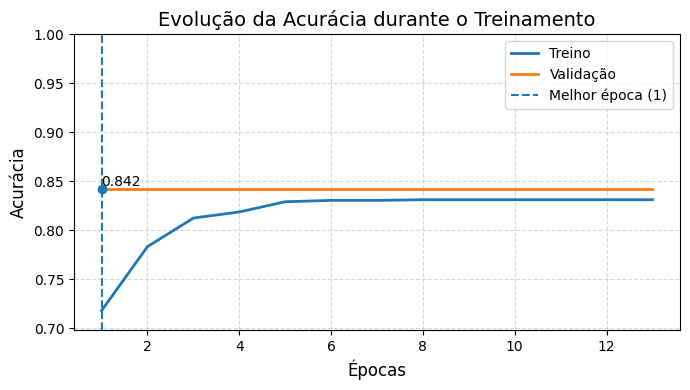

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Dados
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)

# Melhor época (baseado na validação)
best_epoch = np.argmax(val_acc) + 1
best_val_acc = val_acc[best_epoch - 1]

# ================================
# GRÁFICO DE ACURACIA
# ================================

plt.figure(figsize=(7, 4))

# Linha de treino
plt.plot(epochs, acc,
         label='Treino',
         linewidth=2)

# Linha de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2)

# Linha vertical na melhor época
plt.axvline(best_epoch,
            linestyle='--',
            label=f'Melhor época ({best_epoch})')

# Marcar o ponto de melhor acurácia
plt.scatter(best_epoch, best_val_acc, zorder=3)
plt.text(best_epoch, best_val_acc,
         f"{best_val_acc:.3f}",
         ha='left', va='bottom')

# Títulos e rótulos
plt.title('Evolução da Acurácia durante o Treinamento', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)

# Grade
plt.grid(True, linestyle='--', alpha=0.5)

# Limites
plt.ylim(min(acc) - 0.02, 1.0)

# Legenda
plt.legend()

# Ajuste final
plt.tight_layout()

plt.show()

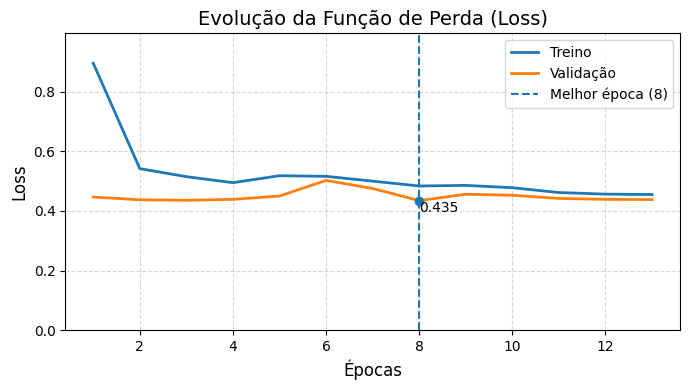

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Dados
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

# Melhor época (menor loss de validação)
best_epoch = np.argmin(val_loss) + 1
best_val_loss = val_loss[best_epoch - 1]

# ================================
# GRÁFICO DE LOSS
# ================================

plt.figure(figsize=(7, 4))

# Linha de treino
plt.plot(epochs, loss,
         label='Treino',
         linewidth=2)

# Linha de validação
plt.plot(epochs, val_loss,
         label='Validação',
         linewidth=2)

# Linha vertical na melhor época
plt.axvline(best_epoch,
            linestyle='--',
            label=f'Melhor época ({best_epoch})')

# Marcar ponto de menor loss
plt.scatter(best_epoch, best_val_loss, zorder=3)
plt.text(best_epoch, best_val_loss,
         f"{best_val_loss:.3f}",
         ha='left', va='top')

# Títulos e rótulos
plt.title('Evolução da Função de Perda (Loss)', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# Grade elegante
plt.grid(True, linestyle='--', alpha=0.5)

# Ajuste automático do eixo Y
plt.ylim(0, max(loss) + 0.1)

# Legenda
plt.legend()

# Ajuste final
plt.tight_layout()

plt.show()

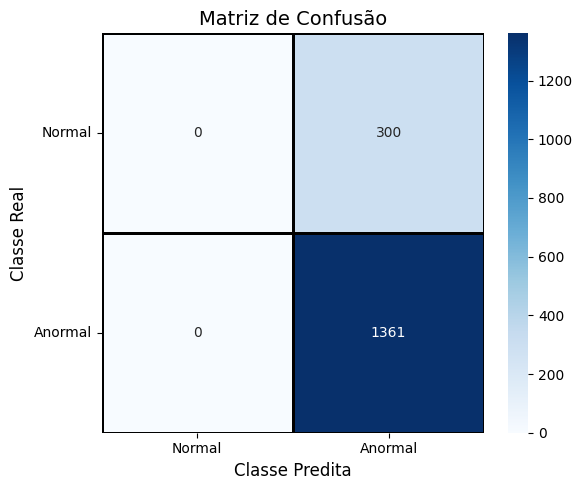

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ================================
# MATRIZ DE CONFUSÃO
# ================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',           # melhora visual
    cbar=True,              # barra de cores
    linewidths=1,           # linhas entre células
    linecolor='black'
)

# Rótulos mais descritivos
plt.xlabel('Classe Predita', fontsize=12)
plt.ylabel('Classe Real', fontsize=12)

# Nome das classes
plt.xticks([0.5, 1.5], ['Normal', 'Anormal'])
plt.yticks([0.5, 1.5], ['Normal', 'Anormal'], rotation=0)

plt.title('Matriz de Confusão', fontsize=14)

plt.tight_layout()
plt.show()

## 🖊️ Análise Crítica

Apesar dos resultados positivos, é importante destacar algumas limitações do modelo. A arquitetura MLP não é ideal para dados de imagem, pois não considera relações espaciais entre os pixels, o que pode limitar sua capacidade de extração de características relevantes.

Além disso, o dataset apresenta certo nível de desbalanceamento entre as classes, o que pode influenciar o desempenho do modelo, favorecendo a classe majoritária.

Pequenas variações nos resultados também são esperadas devido à natureza estocástica do treinamento de redes neurais, incluindo inicialização aleatória de pesos e uso de técnicas como Dropout.

## 📝 Conclusão

Neste trabalho, foi possível aplicar uma Rede Neural Artificial do tipo MLP para classificação de imagens de ECG, distinguindo entre padrões normais e anormais.

Os resultados demonstraram que o modelo é capaz de aprender padrões relevantes, alcançando desempenho satisfatório na tarefa proposta. No entanto, limitações relacionadas à arquitetura utilizada e à complexidade dos dados foram observadas.

Como trabalhos futuros, sugere-se a utilização de Redes Neurais Convolucionais (CNN), que são mais adequadas para análise de imagens, podendo melhorar significativamente o desempenho do modelo.

Dessa forma, conclui-se que a Inteligência Artificial possui grande potencial no apoio ao diagnóstico médico, especialmente na triagem automatizada de pacientes.
